Libraries Imported Successfully

Upload an Image


Saving 2.jpg to 2 (1).jpg


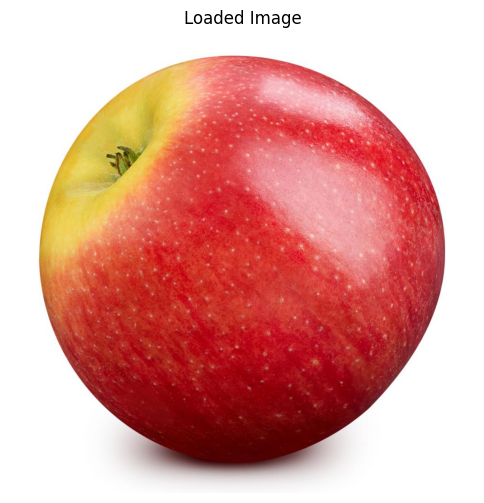


Image Properties
---------------------------
Shape : (1016, 1024, 3)
Height: 1016
Width : 1024
Channels: 3
Datatype: uint8


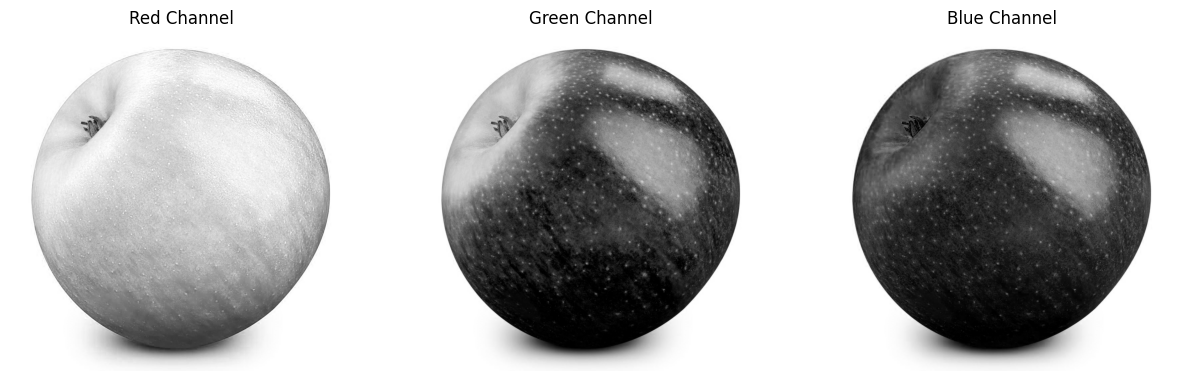


Click Capture to take Webcam Photo


<IPython.core.display.Javascript object>

MessageError: NotFoundError: Requested device not found

In [2]:
# ==========================================================
# MACHINE VISION ENVIRONMENT SETUP & BASIC IMAGE OPERATIONS
# Google Colab
# ==========================================================

# Install OpenCV
!pip -q install opencv-python-headless

# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode

print("Libraries Imported Successfully")

# ==========================================================
# IMAGE LOADING
# ==========================================================

print("\nUpload an Image")

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==========================================================
# IMAGE DISPLAY
# ==========================================================

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Loaded Image")
plt.axis("off")
plt.show()

# ==========================================================
# IMAGE PROPERTIES
# ==========================================================

print("\nImage Properties")
print("---------------------------")
print("Shape :", img.shape)
print("Height:", img.shape[0])
print("Width :", img.shape[1])
print("Channels:", img.shape[2])
print("Datatype:", img.dtype)

# ==========================================================
# COLOR CHANNELS
# ==========================================================

b,g,r = cv2.split(img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(r,cmap='gray')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(g,cmap='gray')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(b,cmap='gray')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

# ==========================================================
# WEBCAM IMAGE CAPTURE
# ==========================================================

def take_photo(filename='webcam.jpg', quality=0.9):

    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video:true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.body.scrollHeight, true);

      await new Promise((resolve)=>capture.onclick=resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video,0,0);

      stream.getTracks().forEach(track=>track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg',quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename,'wb') as f:
        f.write(binary)

    return filename

print("\nClick Capture to take Webcam Photo")

filename = take_photo()

webcam = cv2.imread(filename)
webcam = cv2.cvtColor(webcam, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(webcam)
plt.title("Captured Webcam Image")
plt.axis("off")
plt.show()

# ==========================================================
# VIDEO DEMONSTRATION
# ==========================================================

print("\nVideo Capture in Google Colab")
print("--------------------------------")
print("Google Colab does not support live video streaming using cv2.VideoCapture().")
print("Instead, webcam images can be captured as demonstrated above.")
print("For continuous video capture, run the code in VS Code or Jupyter Notebook on your local machine.")

print("\nProgram Completed Successfully.")